# 🥭 Tropical Fruits Classification Model

Selamat datang di modul Klasifikasi Buah Tropis! Notebook ini memandu Anda membuat model Machine Learning untuk merekomendasikan jenis buah tropis yang cocok ditanam berdasarkan kondisi tanah dan cuaca.

Dataset yang digunakan adalah `crop_buah_tropis.csv` (1.200 baris data) yang mencakup 4 kelas buah tropis:
- **Banana** (Pisang)
- **Mango** (Mangga)
- **Papaya** (Pepaya)
- **Watermelon** (Semangka)

Fitur input meliputi Nitrogen (N), Fosfor (P), Kalium (K), suhu (temperature), kelembapan (humidity), pH tanah (ph), dan curah hujan (rainfall).

## 1. Persiapan Library

Langkah pertama adalah mengimpor semua library Python yang dibutuhkan, seperti `pandas` untuk manipulasi data, `matplotlib` dan `seaborn` untuk visualisasi, serta `scikit-learn` untuk *Machine Learning*.

In [122]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score

## 2. Data Loading & Eksplorasi Awal

### 2.1. Load Dataset

Membaca dataset ke dalam DataFrame pandas untuk memudahkan manipulasi dan analisis data.

In [123]:
data = pd.read_csv("../dataset/crop_buah_tropis.csv")
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,52,108,48,14.000000,93.568505,7.790062,204.723747,papaya
1,50,85,53,14.000000,99.000000,6.616980,194.919741,papaya
2,84,99,54,28.235199,86.995720,6.518205,89.910024,banana
3,106,14,50,26.178716,80.094251,7.075525,41.342748,watermelon
4,58,60,56,14.000000,95.009529,6.782712,163.002324,papaya


### 2.2. Pembersihan dan Inspeksi Kolom

Melihat sekilas informasi dataset (tipe data, jumlah entri) dan memastikan nama kolom sesuai. Pada dataset buah tropis ini, target klasifikasi kita ada di kolom `label` (4 jenis buah).

In [124]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2400 non-null   int64  
 1   P            2400 non-null   int64  
 2   K            2400 non-null   int64  
 3   temperature  2400 non-null   float64
 4   humidity     2400 non-null   float64
 5   ph           2400 non-null   float64
 6   rainfall     2400 non-null   float64
 7   label        2400 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 150.1 KB


### 2.3. Statistik Deskriptif

Melihat ringkasan statistik (rata-rata, nilai minimum/maksimum, kuartil) dari fitur-fitur numerik untuk memahami distribusi dasar dari data.

In [125]:
data.describe(include='all')

,N,P,K,temperature,humidity,ph,rainfall,label
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,papaya
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600
mean,68.808750,47.548750,45.245833,29.193165,76.783290,6.238907,103.205386,NaN
std,43.690388,31.039046,12.534853,7.074904,17.607827,0.992082,79.739767,NaN
min,0.000000,0.000000,0.000000,14.000000,20.000000,3.500000,15.000000,NaN
25%,33.750000,22.000000,36.000000,25.122413,62.806735,5.757264,56.765156,NaN
50%,70.000000,45.500000,48.000000,27.781313,82.872013,6.392802,92.989921,NaN
75%,102.000000,72.000000,53.000000,32.570404,90.574305,6.815372,111.670507,NaN


### 2.4. Deteksi Missing Values

Memeriksa apakah terdapat nilai yang hilang (*missing values/NaN*) pada dataset. Data yang hilang perlu ditangani (misalnya diisi atau dihapus) agar tidak mengganggu proses training model.

In [126]:
data_null = data.isnull().sum()
data_null[data_null > 0]

Series([], dtype: int64)

### 2.5. Deteksi Data Duplikat

Memeriksa dan menghapus baris data yang duplikat untuk memastikan model belajar dari informasi yang unik dan bervariasi.

In [127]:
duplicate = data. duplicated()
print(data[duplicate])

Empty DataFrame
Columns: [N, P, K, temperature, humidity, ph, rainfall, label]
Index: []


### 2.6. Pembersihan Fitur dan Distribusi Label

Memastikan fitur sudah bersih dan melihat sekilas komposisi setiap kelas pada kolom target (`label`).

In [128]:
jumlah_unik = data['label'].nunique()
print(f"Jumlah label unik: {jumlah_unik}")

print(data['label'].value_counts())

Jumlah label unik: 4
label
papaya        600
banana        600
watermelon    600
mango         600
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

### 3.1. Distribusi Fitur Numerik (Histogram Grid)

Menganalisis bentuk distribusi frekuensi dari setiap fitur numerik (N, P, K, temperature, humidity, pH, rainfall) menggunakan grid subplot.

**Konsep:**
- Histogram menampilkan sebaran frekuensi nilai fitur
- Kurva KDE (Kernel Density Estimation) memberikan gambaran estimasi bentuk distribusi (normal, skewed/miring, bimodal)

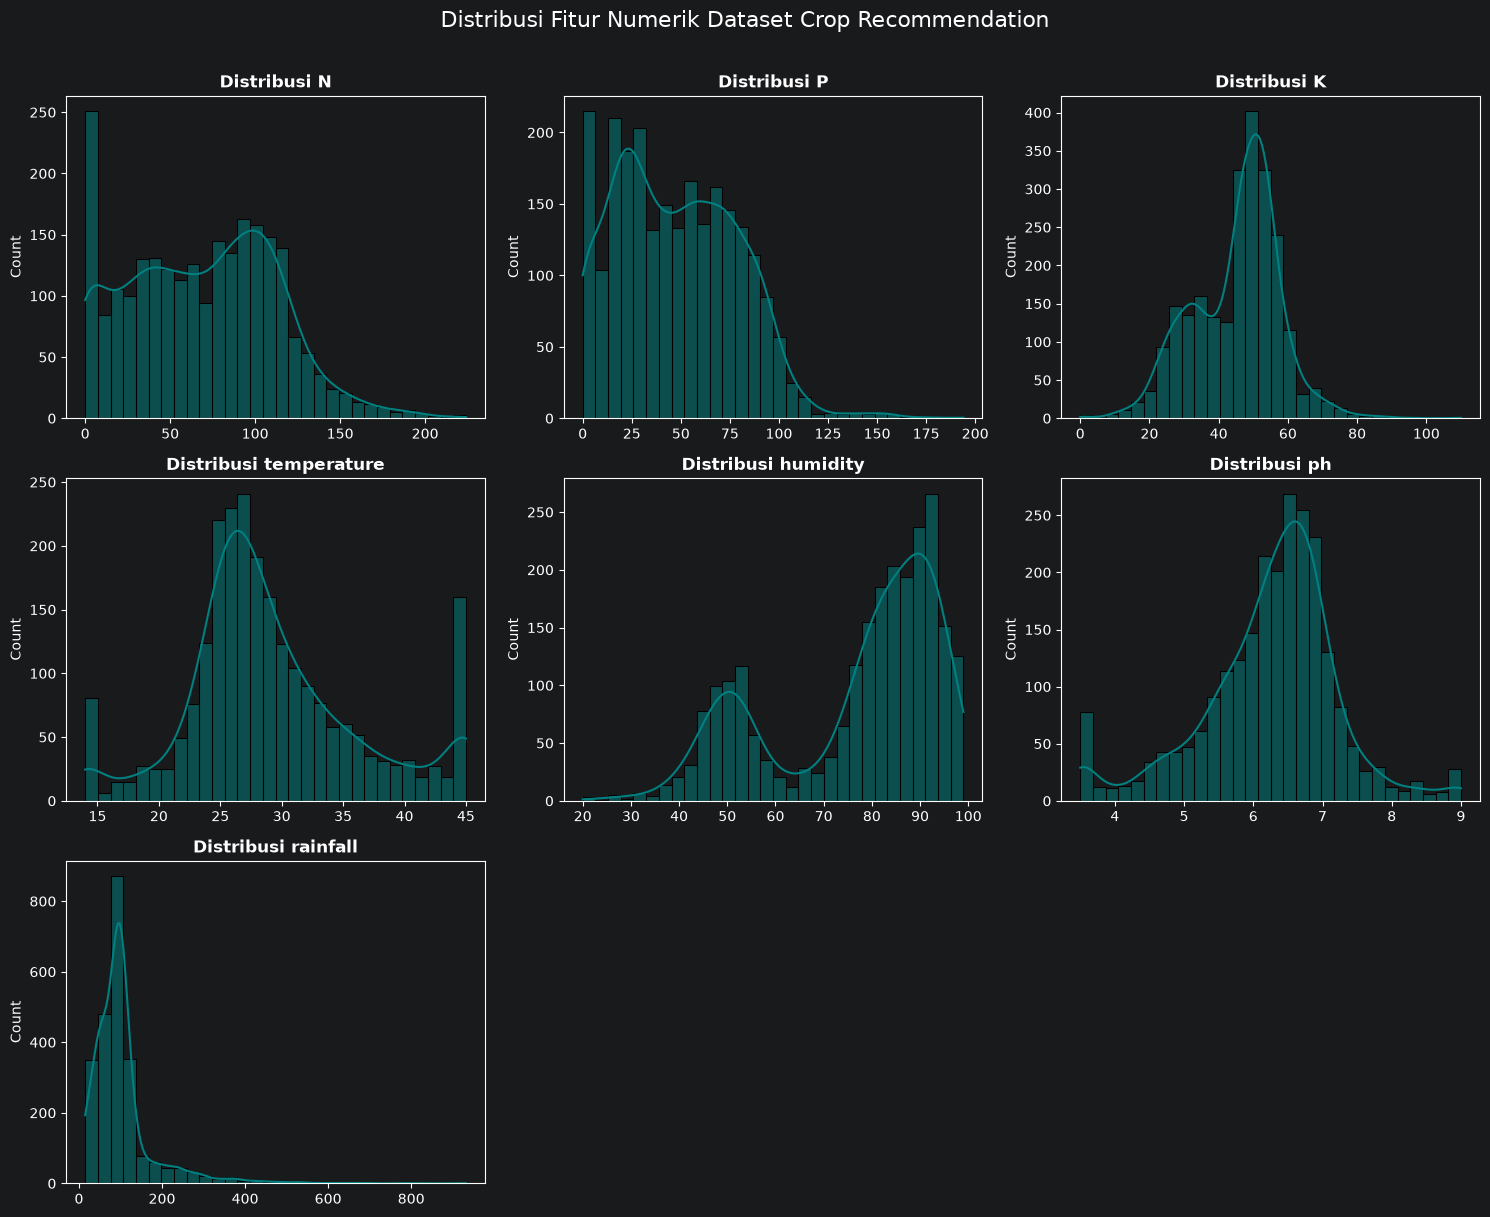

In [129]:
num_features = data.select_dtypes(include=[np.number])
num_cols = num_features.columns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data[col], bins=30, kde=True, color='teal', ax=axes[i])
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

# Hapus subplot kosong jika ada
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik Dataset Crop Recommendation', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.2. Deteksi Outlier (Boxplot Grid)

Melihat sebaran data dan mengidentifikasi nilai ekstrem (*outliers*) menggunakan Box Plot yang ditampilkan dalam satu grid rapi.

**Konsep:**
- Garis tengah box = Median (Q2)
- Batas bawah dan atas box = Kuartil 1 (Q1) dan Kuartil 3 (Q3)
- Titik di luar whisker (gantung) = potensi Outlier

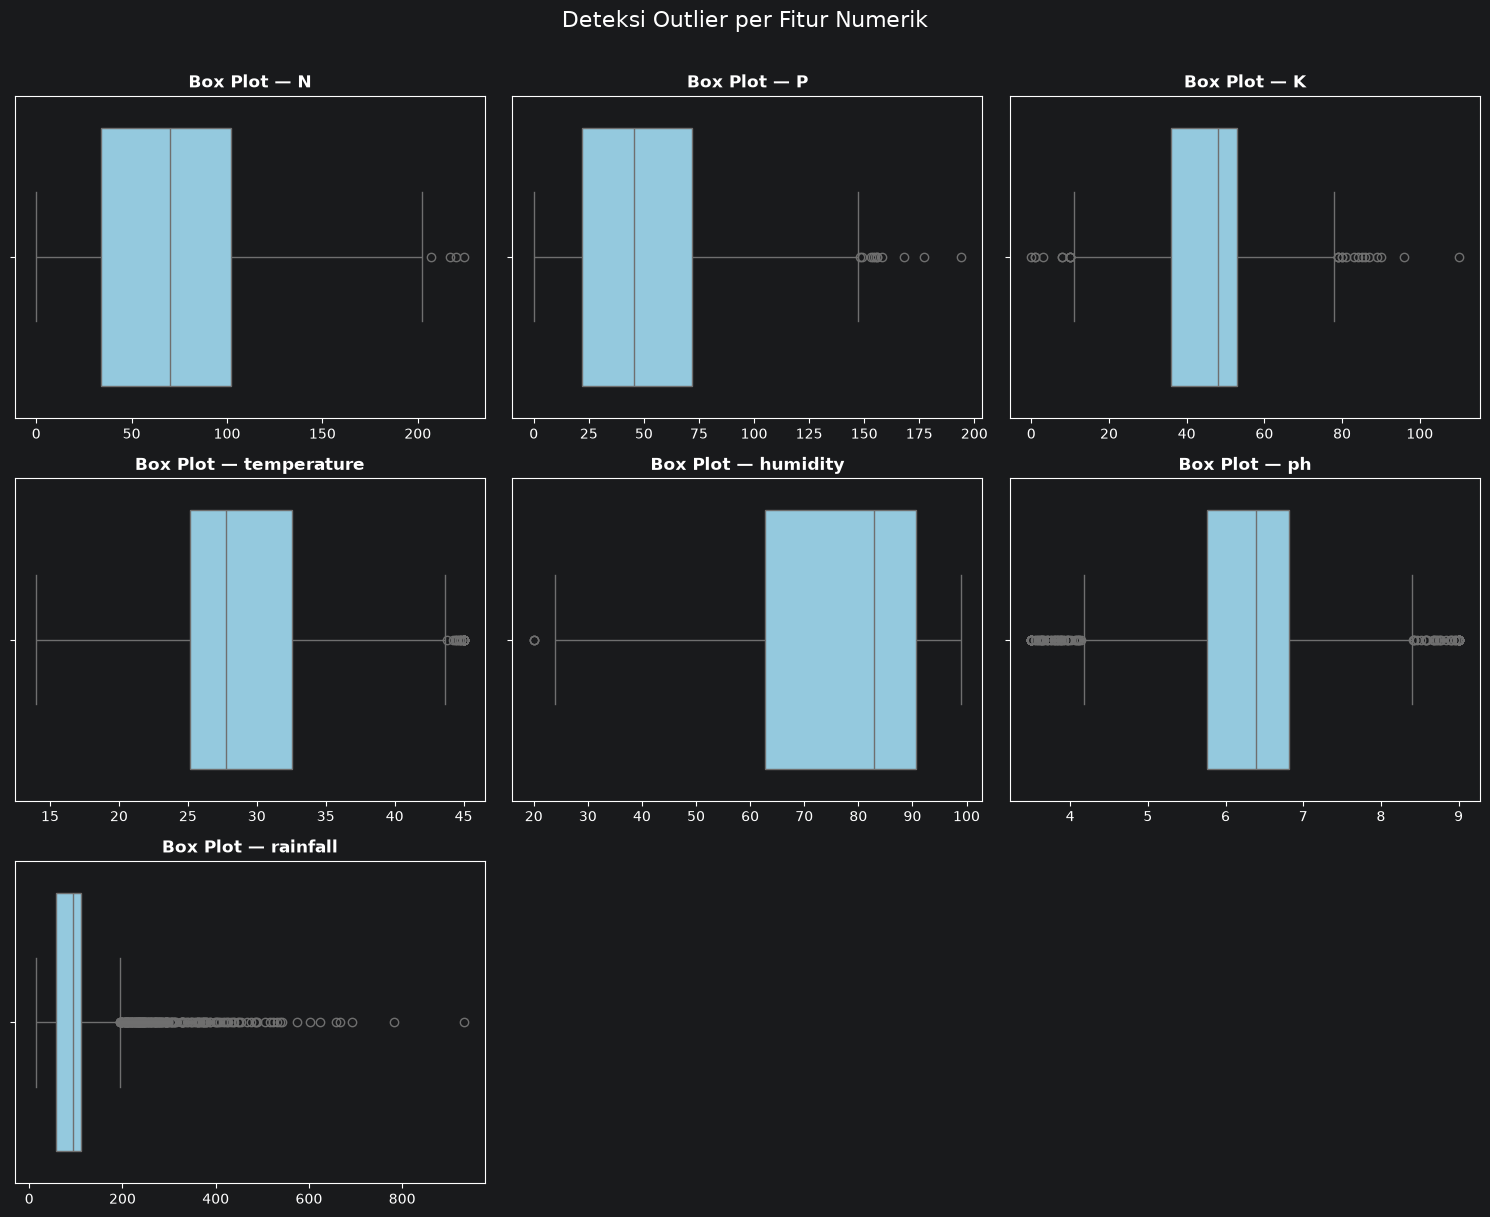

In [130]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=data[col], color='skyblue', ax=axes[i])
    axes[i].set_title(f'Box Plot — {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Deteksi Outlier per Fitur Numerik', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.3. Matriks Korelasi

Menganalisis hubungan korelasi linear antar fitur numerik menggunakan Heatmap Korelasi Pearson.

**Konsep:**
- Nilai mendekati +1 → korelasi positif kuat
- Nilai mendekati -1 → korelasi negatif kuat
- Nilai mendekati 0 → tidak ada hubungan linear

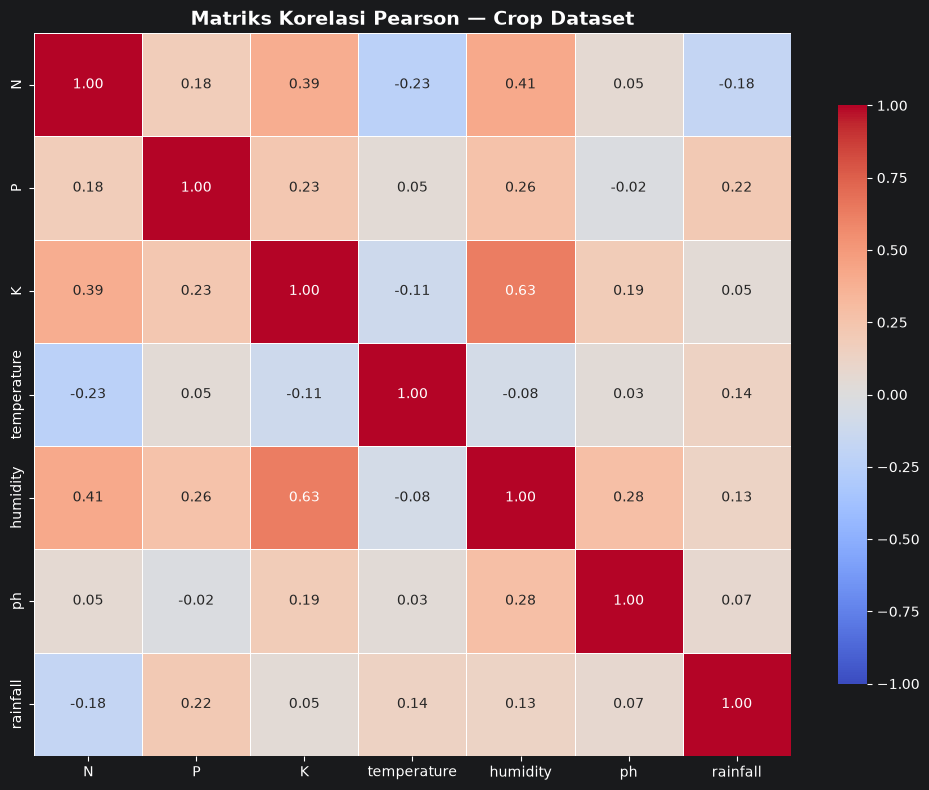

In [131]:
plt.figure(figsize=(10, 8))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Pearson — Crop Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4. Distribusi Label/Target

Mengecek keseimbangan jumlah sampel untuk setiap jenis tanaman (22 jenis tanaman).

/tmp/ipykernel_343106/3777631117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='label', data=data, palette='viridis',


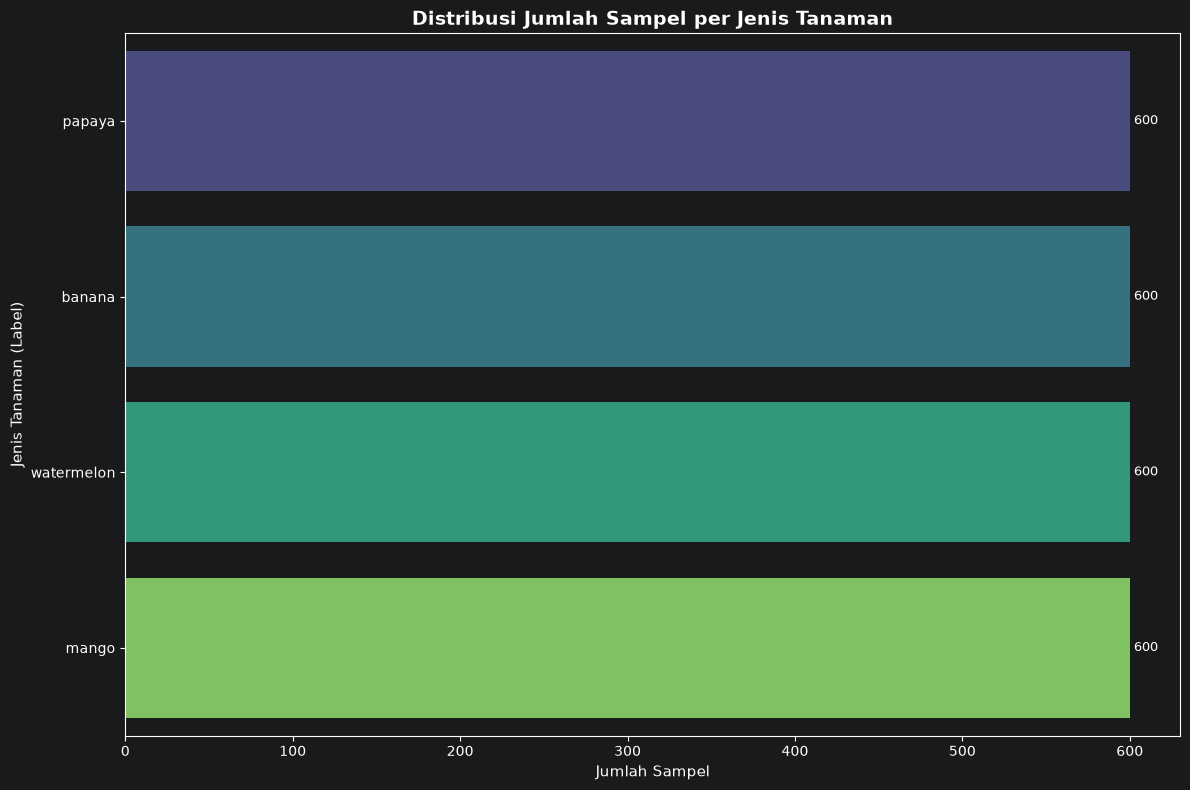

In [132]:
plt.figure(figsize=(12, 8))
ax = sns.countplot(y='label', data=data, palette='viridis',
                   order=data['label'].value_counts().index)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.title('Distribusi Jumlah Sampel per Jenis Tanaman', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Sampel', fontsize=11)
plt.ylabel('Jenis Tanaman (Label)', fontsize=11)
plt.tight_layout()
plt.show()

### 3.5. Rata-Rata Karakteristik Lingkungan per Tanaman

Membuat **Heatmap Rata-Rata** untuk melihat profil kebutuhan tanah dan cuaca ideal bagi masing-masing jenis tanaman secara ringkas dan intuitif.

**Konsep:**
- Setiap sel menunjukkan nilai rata-rata fitur untuk tanaman tersebut
- Memudahkan kita memahami syarat tumbuh tiap tanaman (misal: mana tanaman yang butuh curah hujan tinggi, mana yang butuh Nitrogen tinggi)

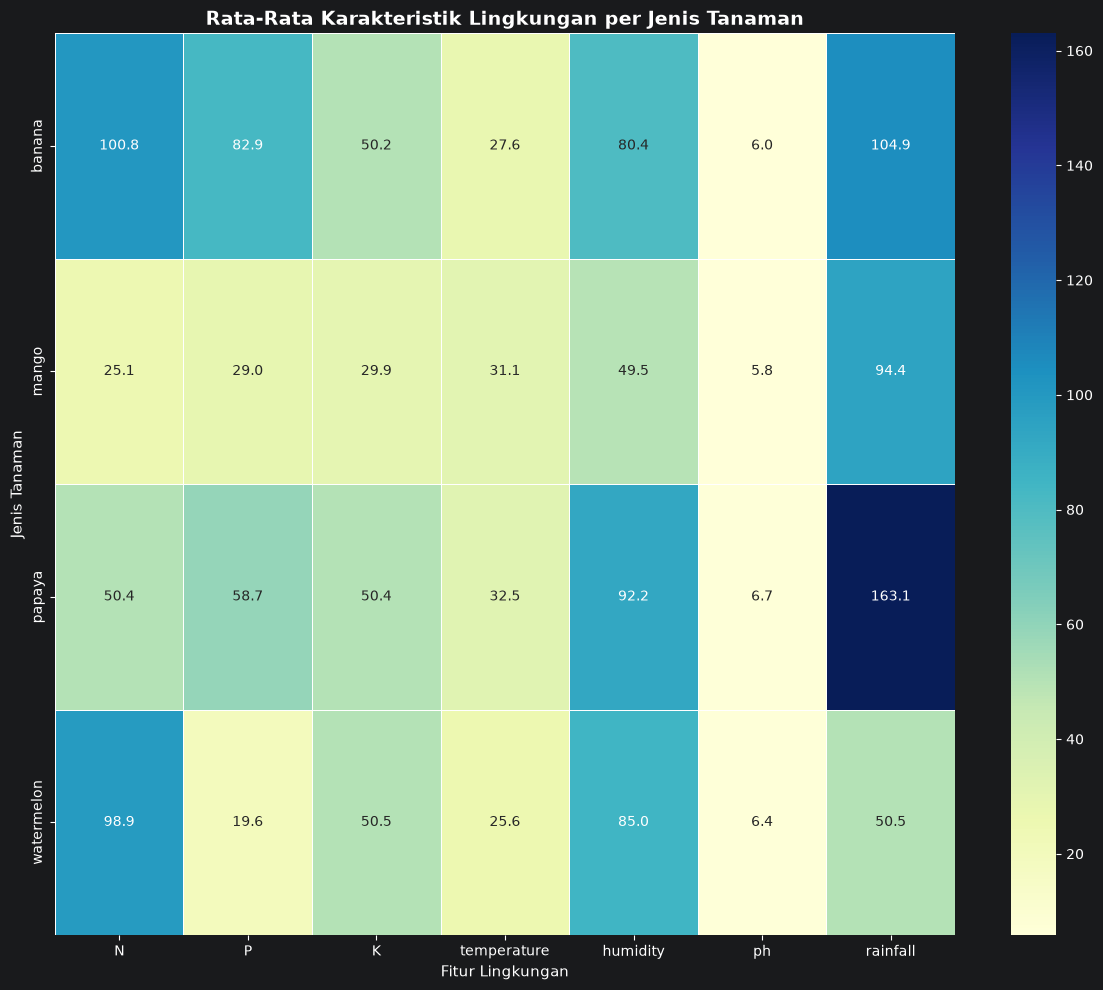

In [133]:
crop_summary = data.groupby('label')[num_cols].mean()

plt.figure(figsize=(12, 10))
sns.heatmap(crop_summary, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('Rata-Rata Karakteristik Lingkungan per Jenis Tanaman', fontsize=14, fontweight='bold')
plt.xlabel('Fitur Lingkungan', fontsize=11)
plt.ylabel('Jenis Tanaman', fontsize=11)
plt.tight_layout()
plt.show()

### 3.6. Analisis Hubungan Nutrisi Tanah (N vs P vs K)

Memvisualisasikan hubungan antara unsur hara Nitrogen (N) dan Fosfor (P) untuk beberapa jenis tanaman utama.

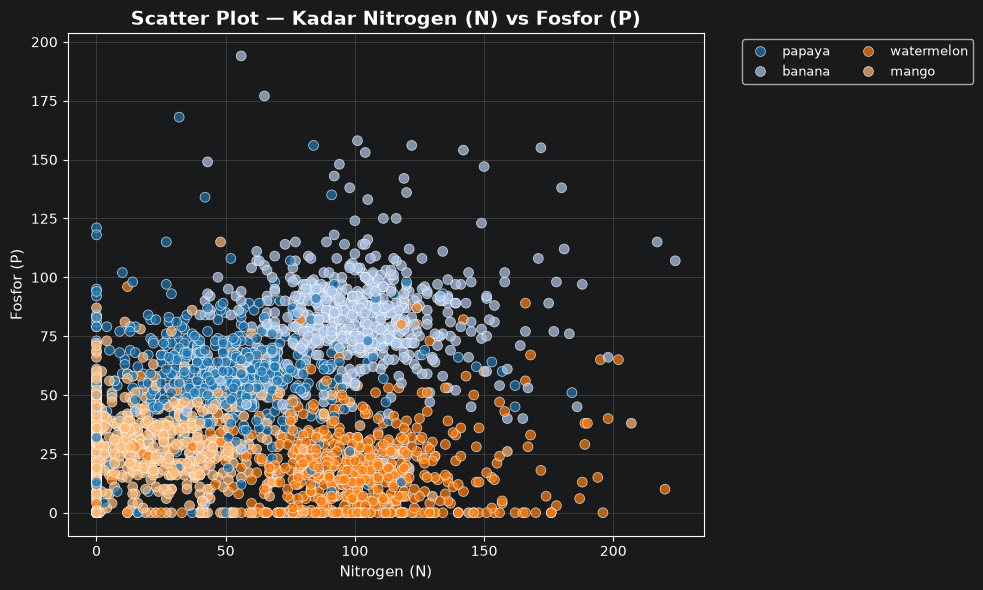

In [134]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='N', y='P', hue='label', data=data, palette='tab20', alpha=0.7, s=50)
plt.title('Scatter Plot — Kadar Nitrogen (N) vs Fosfor (P)', fontsize=14, fontweight='bold')
plt.xlabel('Nitrogen (N)', fontsize=11)
plt.ylabel('Fosfor (P)', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7. Analisis Iklim (Suhu vs Curah Hujan)

Memvisualisasikan hubungan antara Suhu (*Temperature*) dan Curah Hujan (*Rainfall*) terhadap jenis tanaman.

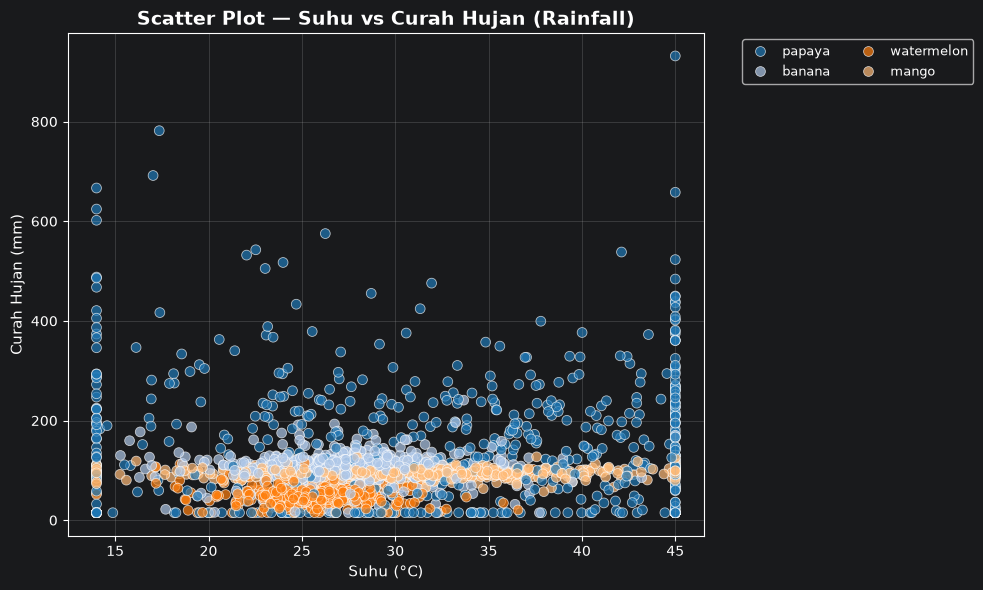

In [135]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature', y='rainfall', hue='label', data=data, palette='tab20', alpha=0.7, s=50)
plt.title('Scatter Plot — Suhu vs Curah Hujan (Rainfall)', fontsize=14, fontweight='bold')
plt.xlabel('Suhu (°C)', fontsize=11)
plt.ylabel('Curah Hujan (mm)', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.8. Analisis Tingkat Keasaman Tanah (pH)

Melihat sebaran tingkat keasaman tanah (pH) yang cocok untuk setiap tanaman.

/tmp/ipykernel_343106/689578316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='ph', data=data, palette='Set3')


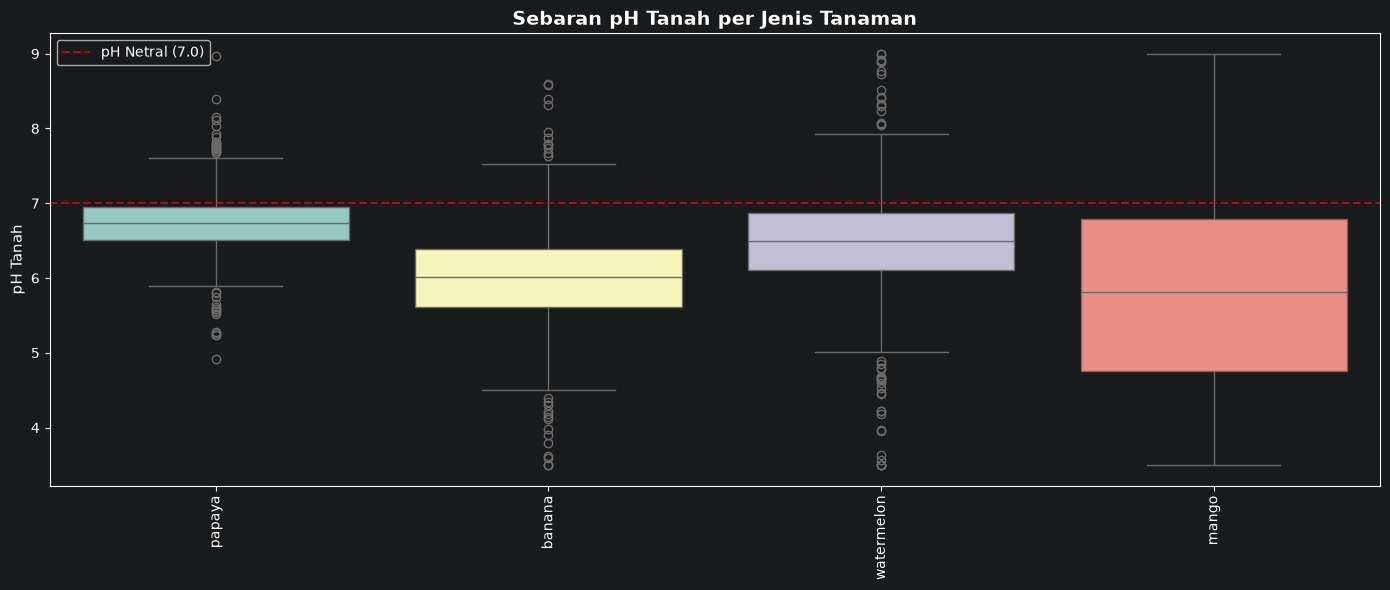

In [136]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='label', y='ph', data=data, palette='Set3')
plt.title('Sebaran pH Tanah per Jenis Tanaman', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('pH Tanah', fontsize=11)
plt.xticks(rotation=90)
plt.axhline(y=7.0, color='red', linestyle='--', alpha=0.7, label='pH Netral (7.0)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

### 4.1. Pisahkan Fitur dan Target

Memisahkan kolom fitur (X) yang akan digunakan untuk memprediksi, dan kolom target/label (y) yang ingin diprediksi.

In [137]:
X = data.drop(columns='label').copy()
y = data['label']

### 4.2. Penanganan Outlier dengan Metode Kuartil (IQR - Interquartile Range)

Mengatasi nilai ekstrem (*outliers*) menggunakan metode rentang antar-kuartil (**IQR**). Nilai di luar batas bawah dan batas atas akan dibatasi (*capping / winsorizing*) agar tidak merusak distribusi data dan pembobotan model.

**Rumus IQR:**
- $Q_1$ = Kuartil 1 (Persentil 25)
- $Q_3$ = Kuartil 3 (Persentil 75)
- $IQR = Q_3 - Q_1$
- $\text{Lower Bound} = Q_1 - 1.5 \times IQR$
- $\text{Upper Bound} = Q_3 + 1.5 \times IQR$

> 💡 **Capping (Winsorizing):** Mengganti nilai $< \text{Lower Bound}$ menjadi $\text{Lower Bound}$, dan nilai $> \text{Upper Bound}$ menjadi $\text{Upper Bound}$ tanpa menghapus baris data.

In [138]:
# Penanganan Outlier dengan metode IQR Capping
num_cols = X.columns

print("📊 Batas IQR untuk setiap fitur:")
for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Hitung jumlah outlier sebelum capping
    n_outliers = ((X[col] < lower_bound) | (X[col] > upper_bound)).sum()
    print(f"   - {col:12s}: Q1={Q1:6.2f}, Q3={Q3:6.2f}, IQR={IQR:6.2f} | Outliers={n_outliers:2d} | Range: [{lower_bound:6.2f}, {upper_bound:6.2f}]")
    
    # Capping nilai di luar batas IQR
    X[col] = np.clip(X[col], lower_bound, upper_bound)

print("\nPenanganan outlier dengan metode IQR Capping selesai!")

📊 Batas IQR untuk setiap fitur:
   - N           : Q1= 33.75, Q3=102.00, IQR= 68.25 | Outliers= 4 | Range: [-68.62, 204.38]
   - P           : Q1= 22.00, Q3= 72.00, IQR= 50.00 | Outliers=11 | Range: [-53.00, 147.00]
   - K           : Q1= 36.00, Q3= 53.00, IQR= 17.00 | Outliers=25 | Range: [ 10.50,  78.50]
   - temperature : Q1= 25.12, Q3= 32.57, IQR=  7.45 | Outliers=161 | Range: [ 13.95,  43.74]
   - humidity    : Q1= 62.81, Q3= 90.57, IQR= 27.77 | Outliers= 3 | Range: [ 21.16, 132.23]
   - ph          : Q1=  5.76, Q3=  6.82, IQR=  1.06 | Outliers=153 | Range: [  4.17,   8.40]
   - rainfall    : Q1= 56.77, Q3=111.67, IQR= 54.91 | Outliers=218 | Range: [-25.59, 194.03]

Penanganan outlier dengan metode IQR Capping selesai!


#### Visualisasi Box Plot Setelah Penanganan Outlier

Menampilkan ulang Box Plot dari seluruh fitur numerik setelah dilakukan penanganan outlier dengan metode IQR Capping.

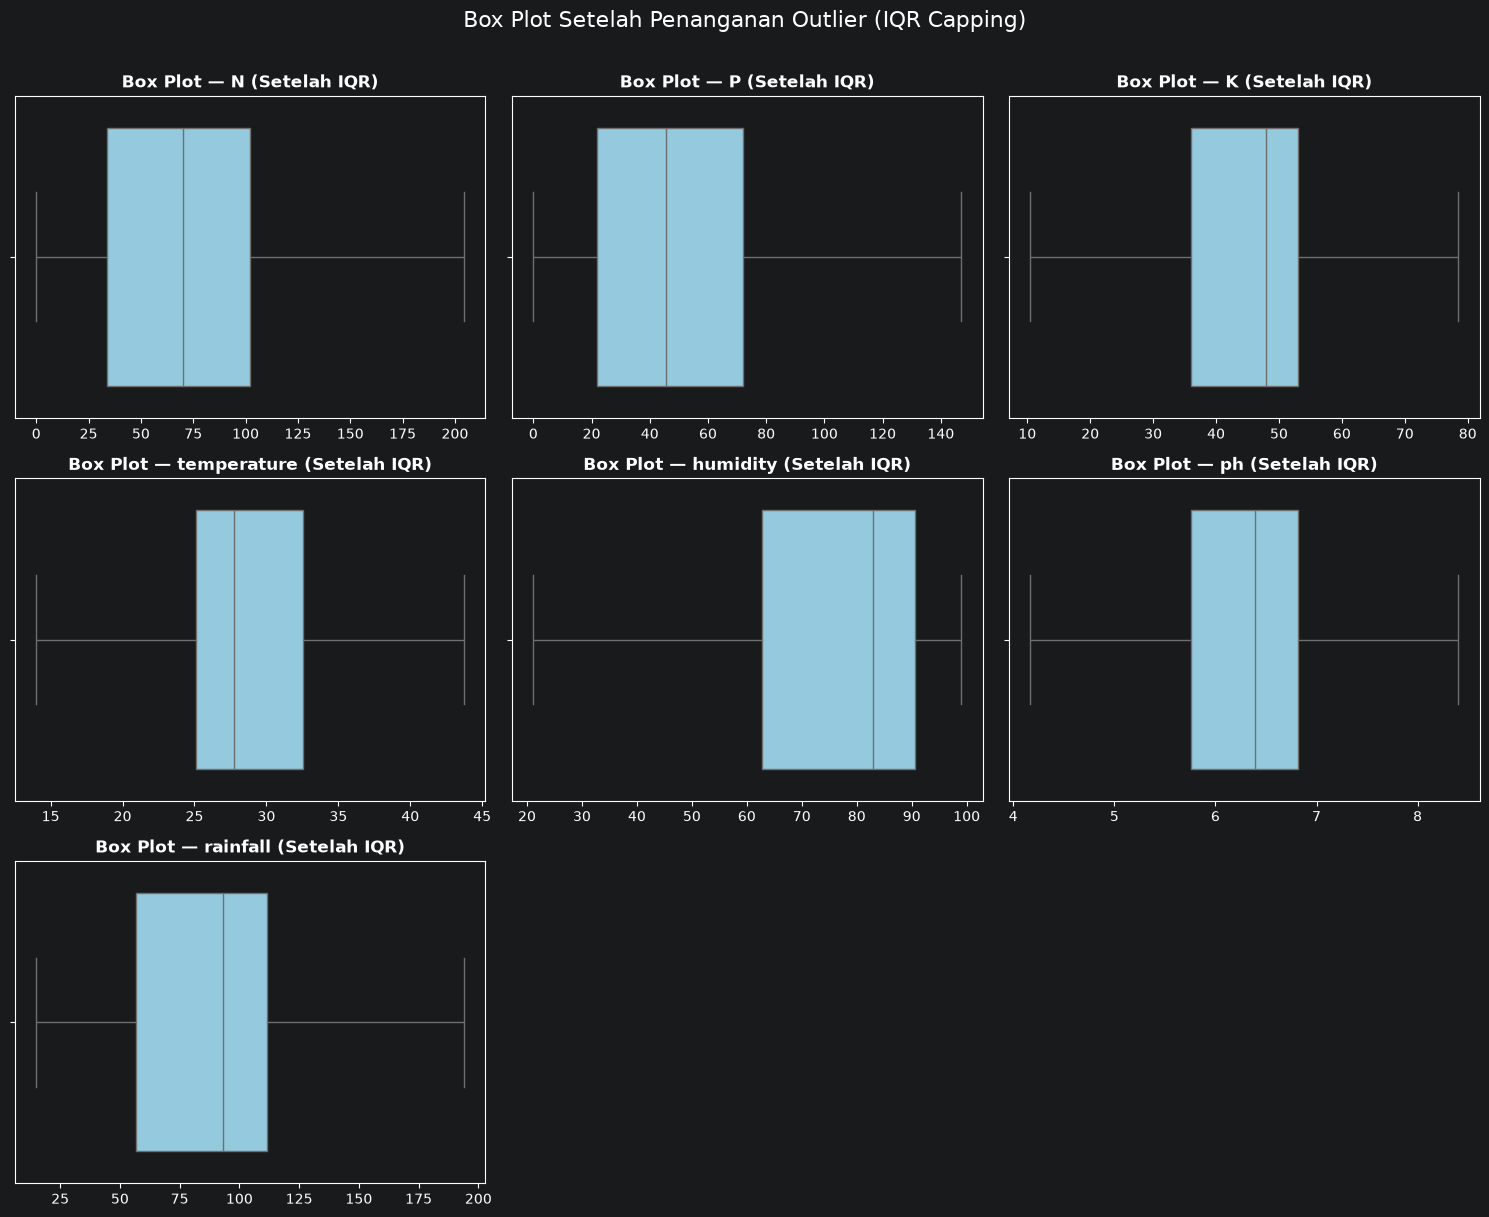

In [139]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.boxplot(x=X[col], color='skyblue', ax=axes[i])
    axes[i].set_title(f'Box Plot — {col} (Setelah IQR)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(X.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Box Plot Setelah Penanganan Outlier (IQR Capping)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 4.3. Standardisasi Fitur (StandardScaler)

Mengubah skala fitur agar memiliki rata-rata 0 dan standar deviasi 1.

In [141]:
scaler = StandardScaler()

X = scaler.fit_transform(X)
X

array([[-0.38493211,  1.96453707,  0.22576551, ...,  0.95364792,
         1.68732126,  2.13931521],
       [-0.43079092,  1.21786311,  0.63154489, ...,  1.26226356,
         0.39766985,  2.13931521],
       [ 0.34880875,  1.67236031,  0.71270077, ...,  0.5801846 ,
         0.28907928, -0.07159523],
       ...,
       [-0.79766135, -0.01577213, -1.96544317, ..., -1.61117775,
        -1.39436705,  0.0807487 ],
       [-0.2702851 , -0.21055665, -1.64081967, ..., -1.95515342,
         1.23969977, -0.011901  ],
       [-0.2473557 , -0.04823622, -0.098858  , ...,  0.85118676,
        -1.02017941, -0.85358763]], shape=(2400, 7))

### 4.4. Encoding Label (LabelEncoder)

Mengubah label kelas berupa teks (kategorikal) menjadi angka (numerik).

In [142]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(y)

[2 2 0 ... 1 1 0]


### 4.5. Bagi Data Latih dan Uji (80:20)

Membagi dataset menjadi 80% data latih dan 20% data uji.

In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

print(f"Train set shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Test set shape: X_test = {X_test.shape}, y_test = {y_test.shape}")

Train set shape: X_train = (1920, 7), y_train = (1920,)
Test set shape: X_test = (480, 7), y_test = (480,)


---
## 5. Model Training

Melatih beberapa algoritma Machine Learning yang berbeda pada data latih. Kita akan menguji model klasifikasi umum seperti Logistic Regression, Decision Tree, Random Forest, SVM, dan KNN.

In [144]:
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)

print("training selesai...")

training selesai...


---
## 6. Model Evaluation

Mengevaluasi kinerja setiap model menggunakan metrik klasifikasi seperti *Accuracy*, *Precision*, *Recall*, dan *F1-Score*.

==== KNN ====
Accuracy  : 0.9750
Precision : 0.9751
Recall    : 0.9750
F1-Score  : 0.9750

Classification Report:
              precision    recall  f1-score   support

      banana       0.97      0.97      0.97       120
       mango       1.00      0.99      1.00       120
      papaya       0.98      0.98      0.98       120
  watermelon       0.95      0.96      0.95       120

    accuracy                           0.97       480
   macro avg       0.98      0.98      0.98       480
weighted avg       0.98      0.97      0.98       480



/tmp/ipykernel_343106/172651801.py:24: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kazu/Programming/OpenSource/mini-bootcamp-artificial-intelligence/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


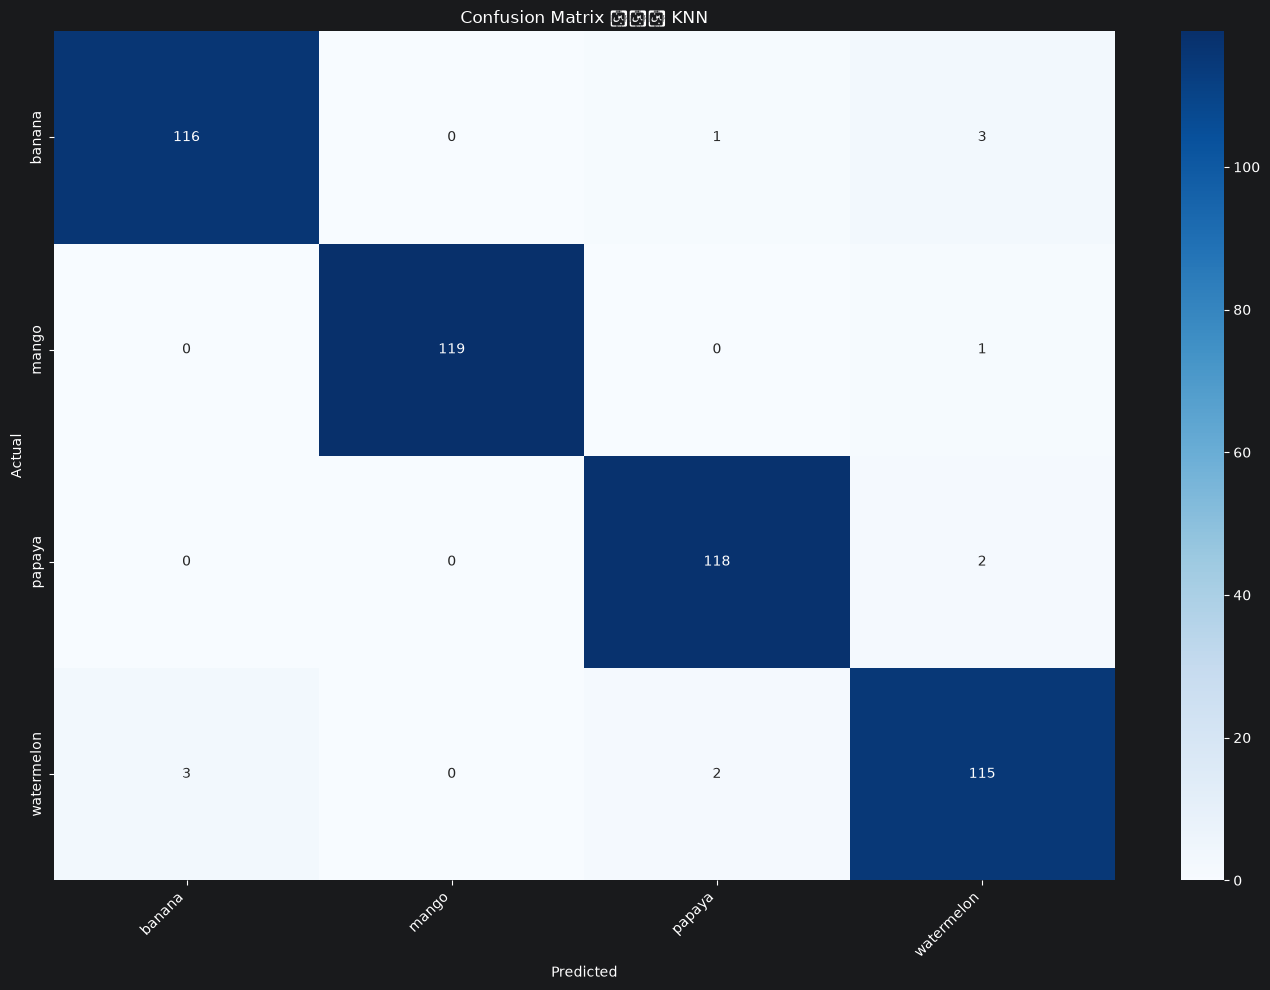



==== Decision Tree ====
Accuracy  : 0.9271
Precision : 0.9273
Recall    : 0.9271
F1-Score  : 0.9269

Classification Report:
              precision    recall  f1-score   support

      banana       0.90      0.91      0.90       120
       mango       0.97      0.98      0.98       120
      papaya       0.94      0.88      0.91       120
  watermelon       0.90      0.93      0.92       120

    accuracy                           0.93       480
   macro avg       0.93      0.93      0.93       480
weighted avg       0.93      0.93      0.93       480



/tmp/ipykernel_343106/172651801.py:24: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kazu/Programming/OpenSource/mini-bootcamp-artificial-intelligence/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


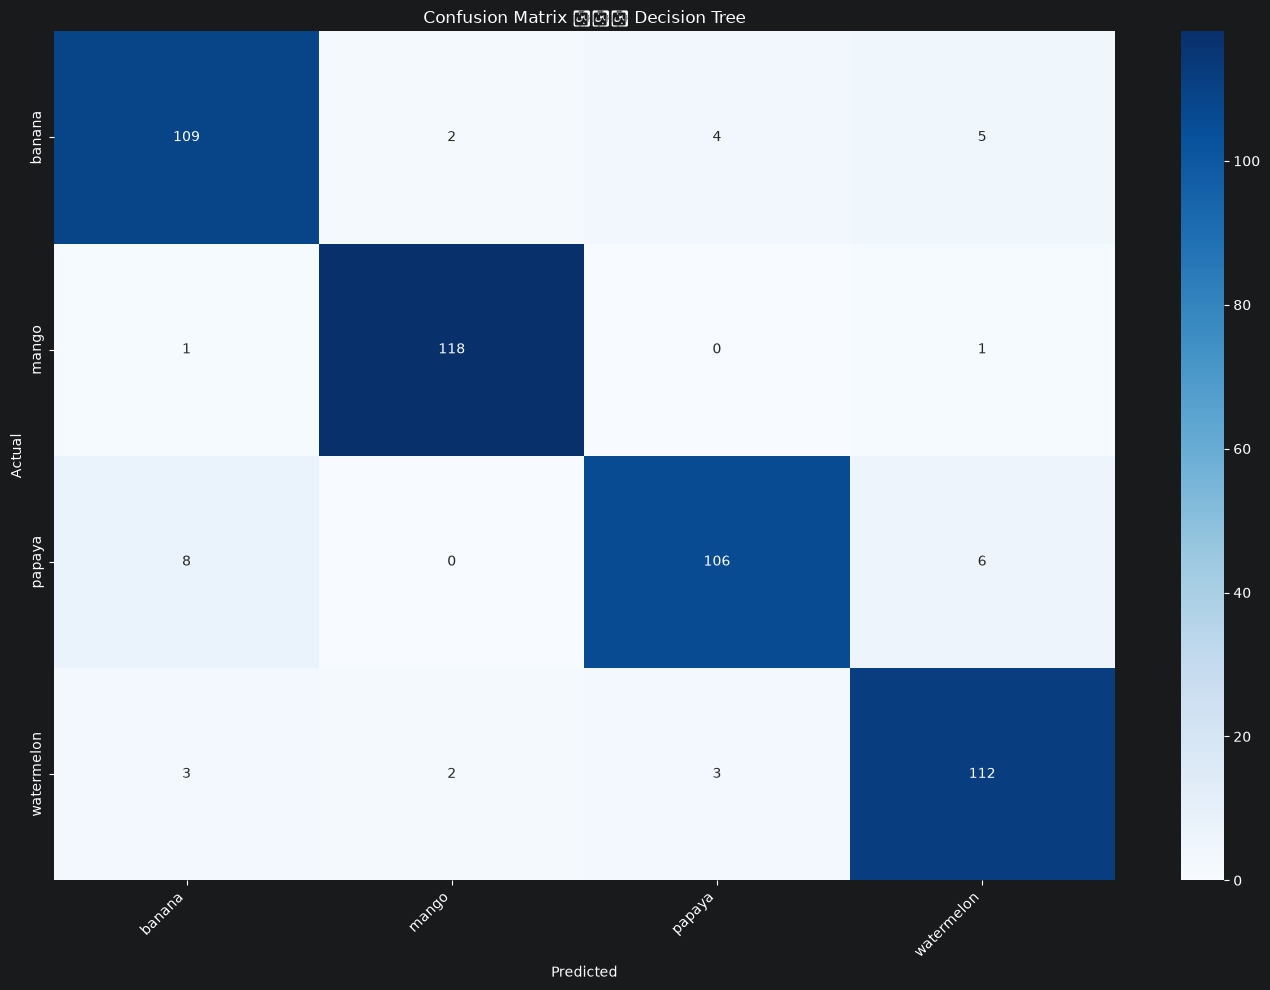



==== Random Forest ====
Accuracy  : 0.9667
Precision : 0.9667
Recall    : 0.9667
F1-Score  : 0.9666

Classification Report:
              precision    recall  f1-score   support

      banana       0.97      0.96      0.97       120
       mango       0.98      1.00      0.99       120
      papaya       0.95      0.97      0.96       120
  watermelon       0.96      0.93      0.95       120

    accuracy                           0.97       480
   macro avg       0.97      0.97      0.97       480
weighted avg       0.97      0.97      0.97       480



/tmp/ipykernel_343106/172651801.py:24: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kazu/Programming/OpenSource/mini-bootcamp-artificial-intelligence/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


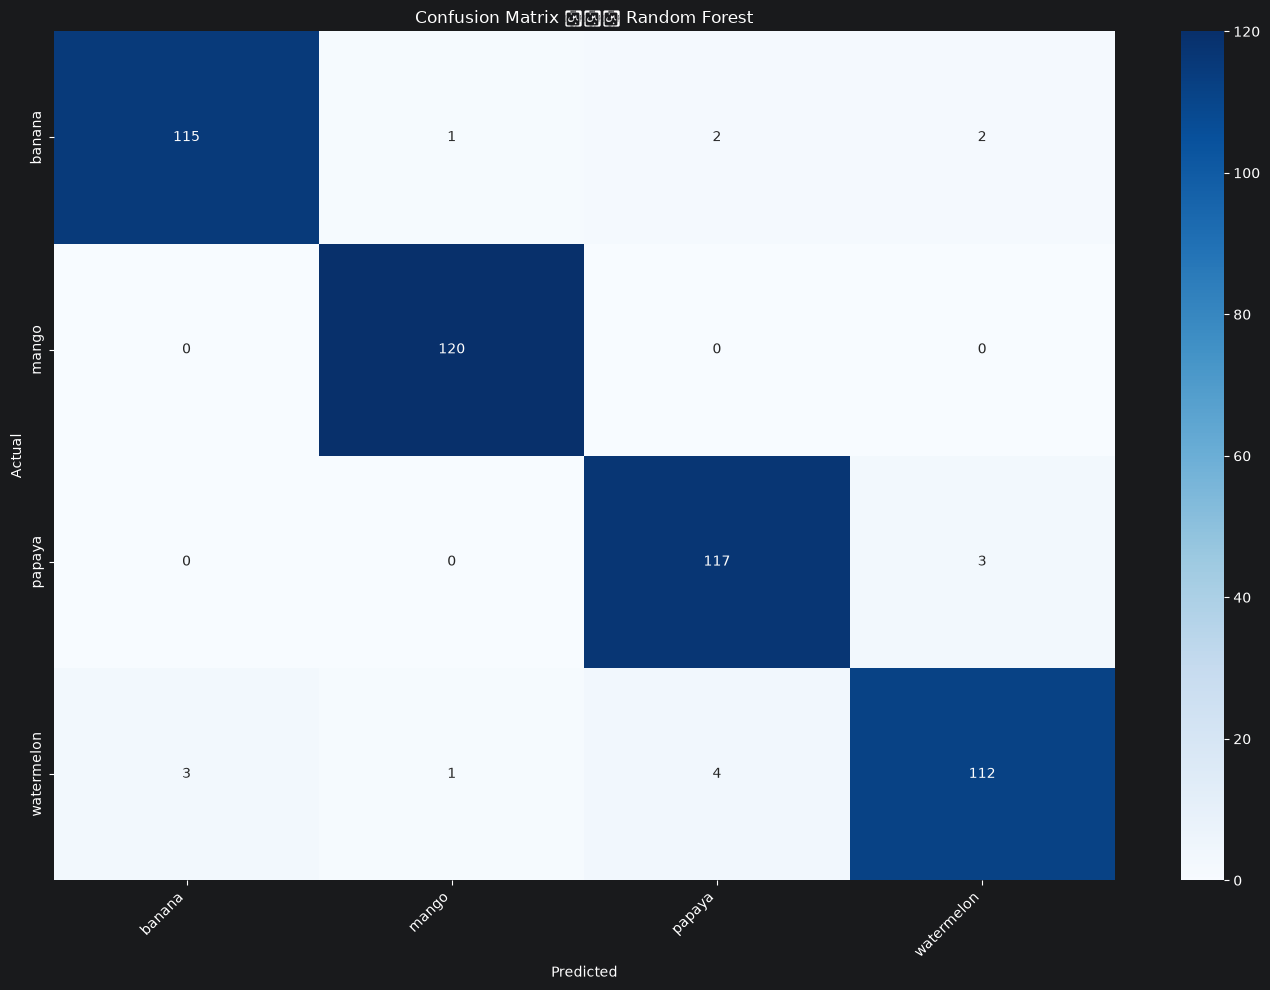



==== SVM ====
Accuracy  : 0.9646
Precision : 0.9645
Recall    : 0.9646
F1-Score  : 0.9645

Classification Report:
              precision    recall  f1-score   support

      banana       0.96      0.97      0.97       120
       mango       0.99      1.00      1.00       120
      papaya       0.97      0.95      0.96       120
  watermelon       0.94      0.93      0.94       120

    accuracy                           0.96       480
   macro avg       0.96      0.96      0.96       480
weighted avg       0.96      0.96      0.96       480



/tmp/ipykernel_343106/172651801.py:24: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kazu/Programming/OpenSource/mini-bootcamp-artificial-intelligence/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


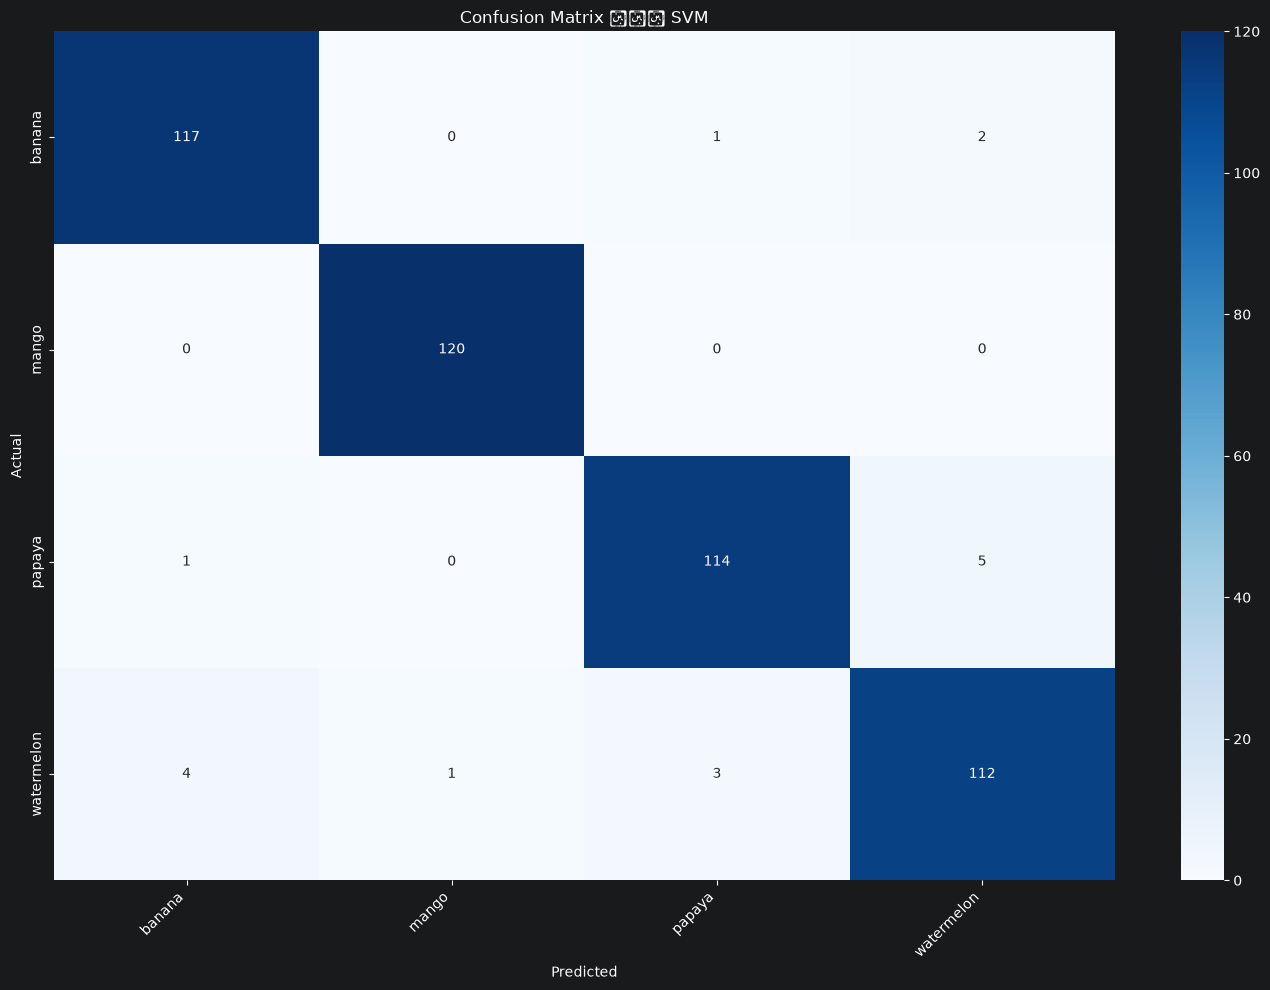



==== Naive Bayes ====
Accuracy  : 0.9750
Precision : 0.9753
Recall    : 0.9750
F1-Score  : 0.9749

Classification Report:
              precision    recall  f1-score   support

      banana       0.96      0.99      0.98       120
       mango       1.00      1.00      1.00       120
      papaya       0.96      0.97      0.97       120
  watermelon       0.98      0.93      0.96       120

    accuracy                           0.97       480
   macro avg       0.98      0.98      0.97       480
weighted avg       0.98      0.97      0.97       480



/tmp/ipykernel_343106/172651801.py:24: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kazu/Programming/OpenSource/mini-bootcamp-artificial-intelligence/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


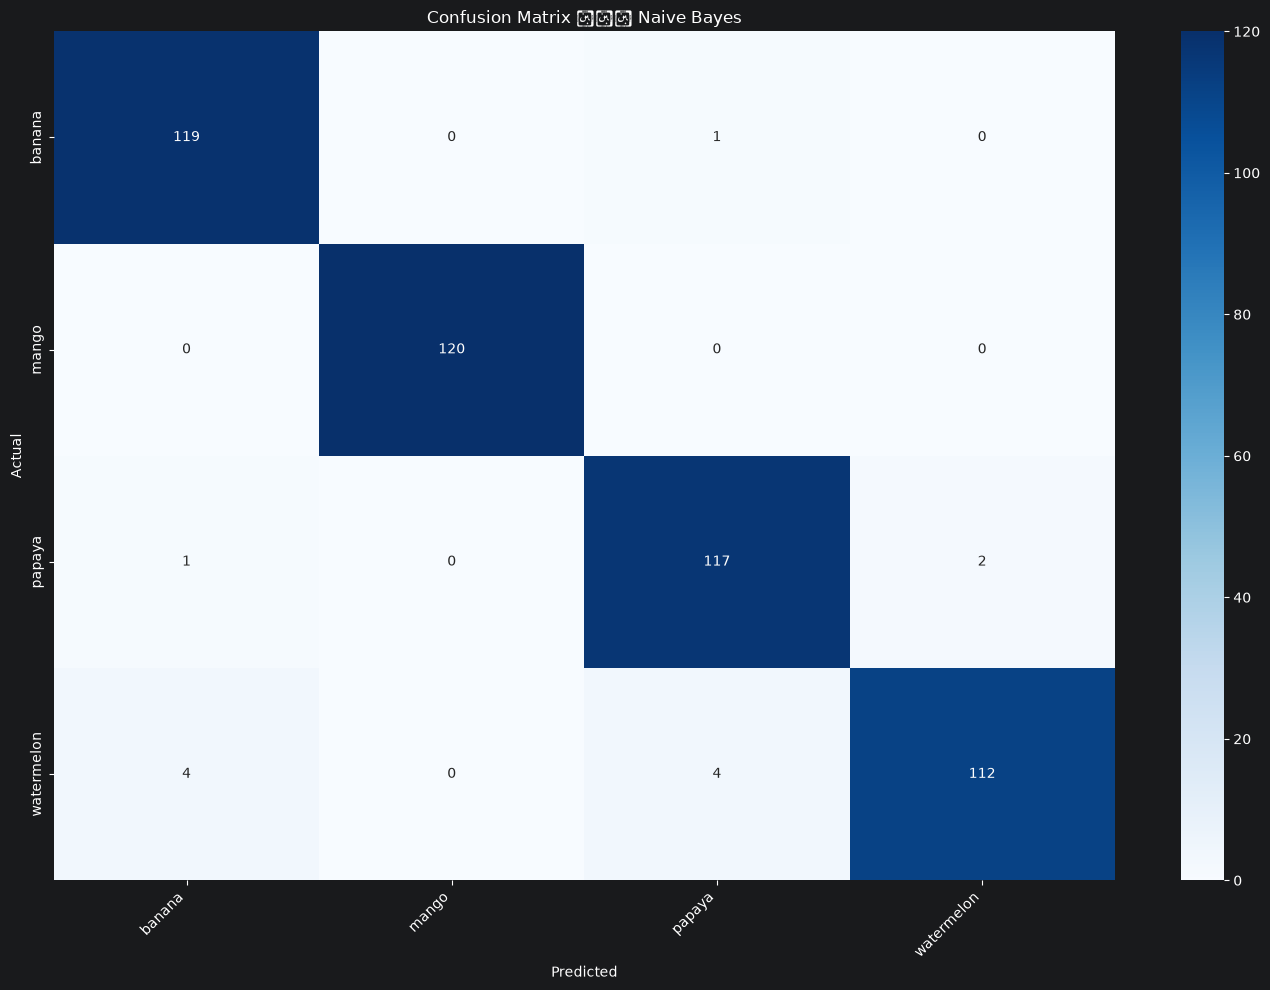

In [145]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def evaluate_model(name, model, X_test, y_test, label_names):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"==== {name} ====")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names))

    #Confusion Matrix
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix ﷿﷿﷿ {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted'),
    }

# Jalankan semua model sekaligus
label_names = label_encoder.classes_  #dari LabelEncoder yang udah lo fit sebelumnya
results = []

results.append(evaluate_model("KNN", knn, X_test, y_test, label_names))
results.append(evaluate_model("Decision Tree", dt, X_test, y_test, label_names))
results.append(evaluate_model("Random Forest", rf, X_test, y_test, label_names))
results.append(evaluate_model("SVM", svm, X_test, y_test, label_names))
results.append(evaluate_model("Naive Bayes", nb, X_test, y_test, label_names))

---
## 7. Model Comparison

Membandingkan performa berbagai model yang telah dilatih secara berdampingan untuk menentukan model mana yang memberikan hasil terbaik secara keseluruhan.

In [146]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    #Untuk multiclass, TP/FP/FN/TN dihitung per kelas lalu dijumlah
    tp = cm.diagonal().sum()                        #semua prediksi benar
    fp = cm.sum(axis=0) - cm.diagonal()            #diprediksi X tapi bukan X
    fn = cm.sum(axis=1) - cm.diagonal()            #seharusnya X tapi diprediksi lain
    tn = cm.sum() - (tp + fp.sum() + fn.sum())     #semua yang bukan kelas itu & benar

    result = {
        "Confusion Matrix": cm,
        "True Positive":  tp,
        "False Positive": fp.sum(),
        "False Negative": fn.sum(),  #fix: sebelumnya salah tulis tp
        "True Negative":  tn,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall":    recall_score(y_test, y_pred, average='weighted'),  #fix typo
        "F1-Score":  f1_score(y_test, y_pred, average='weighted')
    }
    return result

# evaluasi setiap model (tidak ada perubahan di sini)
result = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)':        evaluate_model(dt,  X_test, y_test),
    'Random Forest (RF)':        evaluate_model(rf,  X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)':          evaluate_model(nb,  X_test, y_test)
}

# summary table ﷿﷿﷿ fix typo "Recal" -> "Recall"
rows = []
for model_name, metrics in result.items():
    rows.append({
        "Model":     model_name,
        "Accuracy":  metrics["Accuracy"],
        "Precision": metrics["Precision"],
        "Recall":    metrics["Recall"],
        "F1-Score":  metrics["F1-Score"]
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

                       Model  Accuracy  Precision   Recall  F1-Score
   K-Nearest Neighbors (KNN)  0.975000   0.975102 0.975000  0.975034
          Decision Tree (DT)  0.927083   0.927330 0.927083  0.926919
          Random Forest (RF)  0.966667   0.966667 0.966667  0.966558
Support Vector Machine (SVM)  0.964583   0.964508 0.964583  0.964504
            Naive Bayes (NB)  0.975000   0.975287 0.975000  0.974904


---
## 8. Visualisasi Performa Model

### 8.1. Visualizing Model Performance

Membuat grafik perbandingan metrik evaluasi dari semua model agar lebih mudah dipahami secara visual.

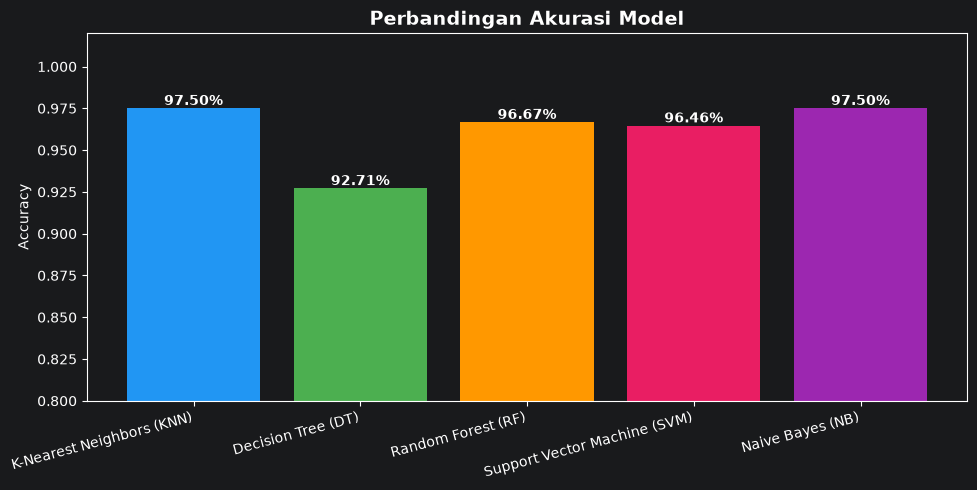

In [147]:
plt.figure(figsize=(10, 5))
bars = plt.bar(summary_df['Model'], summary_df['Accuracy'],
               color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0'])
plt.title('Perbandingan Akurasi Model', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.02)
plt.xticks(rotation=15, ha='right')

# tampilin angka di atas tiap bar
for bar, val in zip(bars, summary_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2. Heatmap Semua Metrik

Menampilkan *heatmap* metrik performa untuk memberikan tampilan yang lebih terstruktur terkait perbandingan antara tiap model terhadap tiap metrik (*Accuracy, Precision, Recall, F1*).

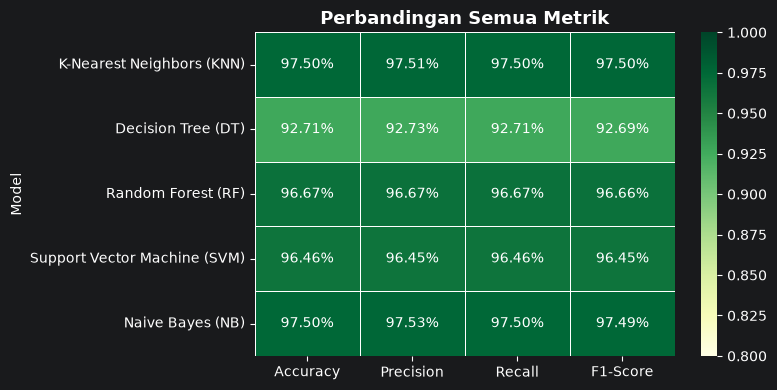

In [148]:
metrics_df = summary_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']]

plt.figure(figsize=(8, 4))
sns.heatmap(metrics_df, annot=True, fmt='.2%', cmap='YlGn',
            vmin=0.8, vmax=1.0, linewidths=0.5)
plt.title('Perbandingan Semua Metrik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Best Model & Error Analysis

Menentukan model terbaik (*Best Model*), kemudian melakukan analisis lanjutan, seperti melihat *Confusion Matrix* untuk mencari tahu di kelas mana model sering melakukan kesalahan klasifikasi (*Error Analysis*).

Model terbaik: K-Nearest Neighbors (KNN)


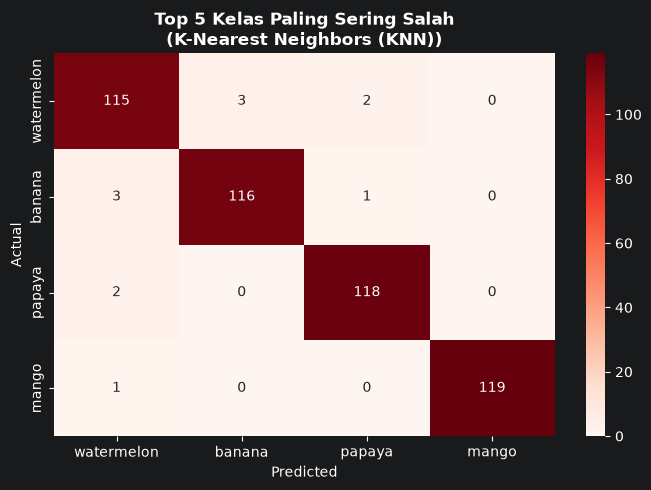

In [149]:
# ambil model terbaik otomatis
best_model_name = summary_df.loc[summary_df['Accuracy'].idxmax(), 'Model']
print(f"Model terbaik: {best_model_name}")

# mapping nama model ke objek
model_map = {
    'K-Nearest Neighbors (KNN)': knn,
    'Decision Tree (DT)': dt,
    'Random Forest (RF)': rf,
    'Support Vector Machine (SVM)': svm,
    'Naive Bayes (NB)': nb
}
best_model = model_map[best_model_name]
y_pred_best = best_model.predict(X_test)

# Tampilkan confusion matrix tapi hanya kelas yang ada error-nya
cm_best = confusion_matrix(y_test, y_pred_best)
errors_per_class = cm_best.sum(axis=1) - cm_best.diagonal()
top5_idx = errors_per_class.argsort()[-5:][::-1]  #5 kelas paling sering salah
top5_labels = label_encoder.classes_[top5_idx]

cm_top5 = cm_best[np.ix_(top5_idx, top5_idx)]

plt.figure(figsize=(7, 5))
sns.heatmap(cm_top5, annot=True, fmt='d', cmap='Reds',
            xticklabels=top5_labels, yticklabels=top5_labels)
plt.title(f'Top 5 Kelas Paling Sering Salah\n({best_model_name})', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

---
## 10. Menyimpan Model (Save Model)

Setelah menemukan model terbaik, langkah selanjutnya adalah menyimpan model beserta `scaler` dan `label_encoder` ke dalam file agar bisa digunakan kembali tanpa harus melatih ulang.

**Konsep:**
- `joblib` → library untuk menyimpan (serialize) dan memuat (deserialize) objek Python secara efisien
- Kita perlu menyimpan **3 komponen**:
  1. **Model** → objek model yang sudah dilatih
  2. **Scaler** → StandardScaler yang sudah di-fit, agar data baru dinormalisasi dengan cara yang sama
  3. **LabelEncoder** → untuk mengonversi hasil prediksi angka kembali ke label asli
- File disimpan ke folder `model/` agar terorganisir

In [150]:
# Buat folder model jika belum ada
os.makedirs('../model', exist_ok=True)

# Simpan model terbaik
joblib.dump(best_model, '../model/best_buah_model.joblib')
print(f"Model '{best_model_name}' berhasil disimpan ke: model/best_buah_model.joblib")

# Simpan scaler
joblib.dump(scaler, '../model/buah_scaler.joblib')
print(f"Scaler berhasil disimpan ke: model/buah_scaler.joblib")

# Simpan label encoder
joblib.dump(label_encoder, '../model/buah_label_encoder.joblib')
print(f"Label Encoder berhasil disimpan ke: model/buah_label_encoder.joblib")

Model 'K-Nearest Neighbors (KNN)' berhasil disimpan ke: model/best_buah_model.joblib
Scaler berhasil disimpan ke: model/buah_scaler.joblib
Label Encoder berhasil disimpan ke: model/buah_label_encoder.joblib


---
## 11. Memuat Model dan Pengujian (Load Model & Testing)

Sekarang kita akan memuat kembali model yang sudah disimpan dan mengujinya dengan data baru untuk membuktikan bahwa model dapat digunakan **tanpa harus melatih ulang**.

**Konsep:**
- `joblib.load()` → memuat objek Python yang telah disimpan sebelumnya
- Alur penggunaan model yang sudah disimpan:
  1. Load model, scaler, dan label encoder dari file
  2. Transformasi data baru menggunakan scaler yang sama (`scaler.transform()`)
  3. Prediksi menggunakan model (`model.predict()`)
  4. Konversi hasil prediksi ke label asli (`label_encoder.inverse_transform()`)

> ⚠️ **Penting:** Gunakan `scaler.transform()` (bukan `fit_transform()`) pada data baru, agar data dinormalisasi dengan parameter yang sama seperti saat training.

In [151]:
# Load model, scaler, dan label encoder
loaded_model = joblib.load('../model/best_buah_model.joblib')
loaded_scaler = joblib.load('../model/buah_scaler.joblib')
loaded_encoder = joblib.load('../model/buah_label_encoder.joblib')

print("Model berhasil dimuat dari: model/best_buah_model.joblib")
print(f"Tipe model: {type(loaded_model).__name__}")
print(f"Label kelas: {list(loaded_encoder.classes_)}")

Model berhasil dimuat dari: model/best_buah_model.joblib
Tipe model: KNeighborsClassifier
Label kelas: ['banana', 'mango', 'papaya', 'watermelon']


### 11.1. Pengujian dengan Data Test Set

Pertama, kita uji model yang dimuat dengan data test set yang sama untuk memastikan hasilnya **identik** dengan model asli.

In [152]:
# Prediksi menggunakan model yang dimuat
y_pred_loaded = loaded_model.predict(X_test)

# Bandingkan dengan prediksi model asli

acc_loaded = accuracy_score(y_test, y_pred_loaded)
acc_original = accuracy_score(y_test, y_pred_best)

print(f"Akurasi model asli     : {acc_original:.4f}")
print(f"Akurasi model dimuat   : {acc_loaded:.4f}")
print()

if acc_loaded == acc_original:
    print("Hasil IDENTIK! Model berhasil disimpan dan dimuat dengan benar.")
else:
    print("Hasil BERBEDA! Ada masalah dalam proses save/load.")

Akurasi model asli     : 0.9750
Akurasi model dimuat   : 0.9750

Hasil IDENTIK! Model berhasil disimpan dan dimuat dengan benar.


### 11.2. Pengujian dengan Data Baru

Sekarang kita coba prediksi menggunakan **data baru yang belum pernah dilihat model**. Ini mensimulasikan penggunaan model di dunia nyata (production).

**Alur:**
1. Buat data baru dalam bentuk DataFrame
2. Transformasi dengan `loaded_scaler.transform()` (⚠️ bukan `fit_transform`!)
3. Prediksi dengan `loaded_model.predict()`
4. Konversi ke label asli dengan `loaded_encoder.inverse_transform()`

In [153]:
# Contoh data baru untuk pengujian (contoh: kondisi tanah untuk buah Mangga/Mango)
# N=20, P=27, K=30, temperature=31.5, humidity=50.2, ph=5.8, rainfall=95.0
data_baru = {
    'N': [20],
    'P': [27],
    'K': [30],
    'temperature': [31.50],
    'humidity': [50.20],
    'ph': [5.80],
    'rainfall': [95.00]
}

df_baru = pd.DataFrame(data_baru)
print("Data input:")
print(df_baru)
print()

# Transformasi data baru menggunakan scaler yang sudah di-load
# Gunakan transform() BUKAN fit_transform()!
data_scaled = loaded_scaler.transform(df_baru)
print("Data setelah di-scale:")
print(data_scaled)
print()

# Prediksi
prediksi = loaded_model.predict(data_scaled)
print(f"Hasil prediksi (numerik): {prediksi}")

# Prediksi jenis buah yang direkomendasikan
prediksi_label = loaded_encoder.inverse_transform(prediksi)
print(f"Buah yang direkomendasikan: {prediksi_label[0]}")

Data input:
    N   P   K  temperature  humidity   ph  rainfall
0  20  27  30         31.5      50.2  5.8      95.0

Data setelah di-scale:
[[-1.11867297 -0.66505384 -1.23504028  0.34656633 -1.51053519 -0.50049372
   0.03648815]]

Hasil prediksi (numerik): [1]
Buah yang direkomendasikan: mango


---
### 📝 Ringkasan Save & Load Model

| Langkah | Fungsi | File |
|---------|--------|------|
| Simpan Model | `joblib.dump(model, path)` | `model/best_crop_model.joblib` |
| Simpan Scaler | `joblib.dump(scaler, path)` | `model/crop_scaler.joblib` |
| Simpan Encoder | `joblib.dump(encoder, path)` | `model/crop_label_encoder.joblib` |
| Muat Model | `joblib.load(path)` | — |
| Transformasi | `scaler.transform(X)` | ⚠️ Bukan `fit_transform`! |
| Prediksi | `model.predict(X_scaled)` | — |
| Decode Label | `encoder.inverse_transform(y)` | — |

> 💡 **Tips:** Selalu simpan **scaler** dan **label encoder** bersama model. Tanpa keduanya, model tidak bisa digunakan dengan benar pada data baru!